In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s6e2/sample_submission.csv
/kaggle/input/playground-series-s6e2/train.csv
/kaggle/input/playground-series-s6e2/test.csv


### Heart Disease Prediction 
## Project Overview:
This notebook walk thorugh a complete machine learning pipline to predict whether a patient has heart disease (binary classification : `0` = No , `1` = Yes)


**Competition:** [Playground Series – Season 6, Episode 2](https://www.kaggle.com/competitions/playground-series-s6e2)  

**Task** : Binary Classification

**Metric** :  ROC-AUC Score

---

## Workflow at a Glance

| Step | What We Do |
|------|------------|
| **1. Setup & Data Loading** | Import libraries, load train/test CSVs |
| **2. Exploratory Data Analysis (EDA)** | Understand distributions, correlations, class balance |
| **3. Data Preprocessing** | Handle missing values, encode categoricals, scale numerics |
| **4. Feature Engineering** | Create meaningful new features from existing ones |
| **5. Baseline Models** | Quickly evaluate 6+ models with default settings |
| **6. Hyperparameter Tuning** | Tune top models via Optuna + GridSearchCV |
| **7. Ensemble / Stacking** | Combine best models for a strong

## Key Strategies

-  **Multiple models** are trained and compared - we never rely on one alone.
-  we use **cross-validation** throughout to prevent overfitting.
-  **optuna** handles automated hyperparameter search for Logistic regression.
-  **GridSearchCV** is used for lighter models like SVM and Logistic Regression.
-  Final prediction use a **soft-voting ensemble** of the top performers.

---

# 1.Setup & Data Loading

In [2]:
#------------CORE LIBRARIES------------
import pandas as pd 
import numpy as np
import warnings
warnings.filterwarnings("ignore")


#------------------Visiualization-----------------
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style="whitegrid" , palette = "muted" , font_scale=1.1)
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']


#---------------Scikit-learn---------------------
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

#----------------------Classical-linear models--------------
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, VotingClassifier, StackingClassifier, AdaBoostClassifier
)
from sklearn.naive_bayes     import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

#-----------------Gradient Boosting Frameworks-----------------------
from xgboost  import XGBClassifier
# from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

#---------------Hyperparameter Tuning--------------
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

#--------------------Utility------------------
from scipy.stats import chi2_contingency
import itertools


SEED = 42
np.random.seed(SEED)

print("ALL libraries loaded successsfully!")

ALL libraries loaded successsfully!


### Load Data(Train,Test,Sample)

In [3]:
#--------------------LOAD DATA-----------------\
train_df = pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv')
test_df  = pd.read_csv('/kaggle/input/playground-series-s6e2/test.csv')
sample   = pd.read_csv('/kaggle/input/playground-series-s6e2/sample_submission.csv')

print(f'Train shape : {train_df.shape}')
print(f'Test shape  : {test_df.shape}')
print(f'Sample sub  : {sample.shape}')
train_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/playground-series-s6e2/train.csv'

### Data Inspection-Data Types & NULL Values

In [3]:
# -------------------Quick overview---------------
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [4]:
train_df.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [5]:
train_df.isnull().sum().sum()

np.int64(0)

# Step 2: Exploratory Data Analysis(EDA)

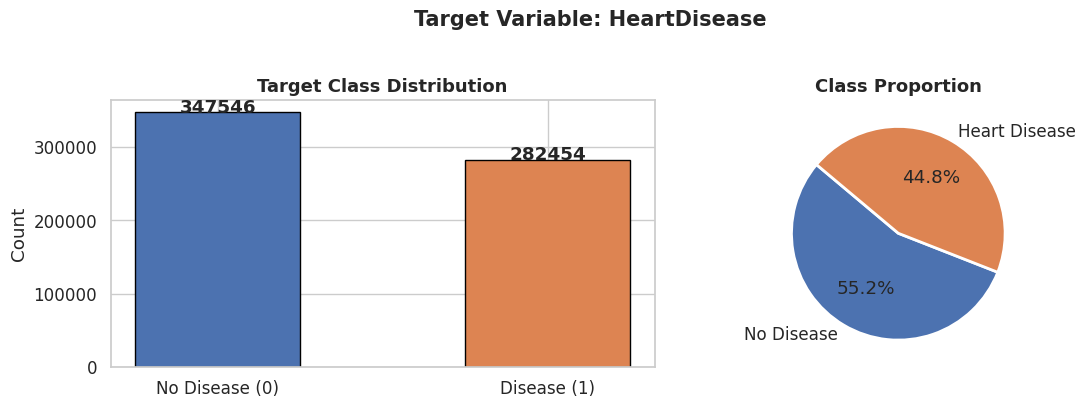


Class Balance: 347546 No Disease | 282454 Heart Disease
Ratio: 0.81


In [6]:
TARGET = 'Heart Disease'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = train_df[TARGET].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values, color=COLORS[:2], edgecolor='black', width=0.5)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No Disease', 'Heart Disease'],
            colors=COLORS[:2], autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: HeartDisease', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nClass Balance: {counts[0]} No Disease | {counts[1]} Heart Disease")
print(f"Ratio: {counts[1]/counts[0]:.2f}")

### 2.2 — Numerical Feature Distributions-Checking outliers

In [7]:
train_df.select_dtypes(include=np.number).columns.drop(["id" , "Heart Disease"] , errors="ignore").tolist()

['Age',
 'Sex',
 'Chest pain type',
 'BP',
 'Cholesterol',
 'FBS over 120',
 'EKG results',
 'Max HR',
 'Exercise angina',
 'ST depression',
 'Slope of ST',
 'Number of vessels fluro',
 'Thallium']

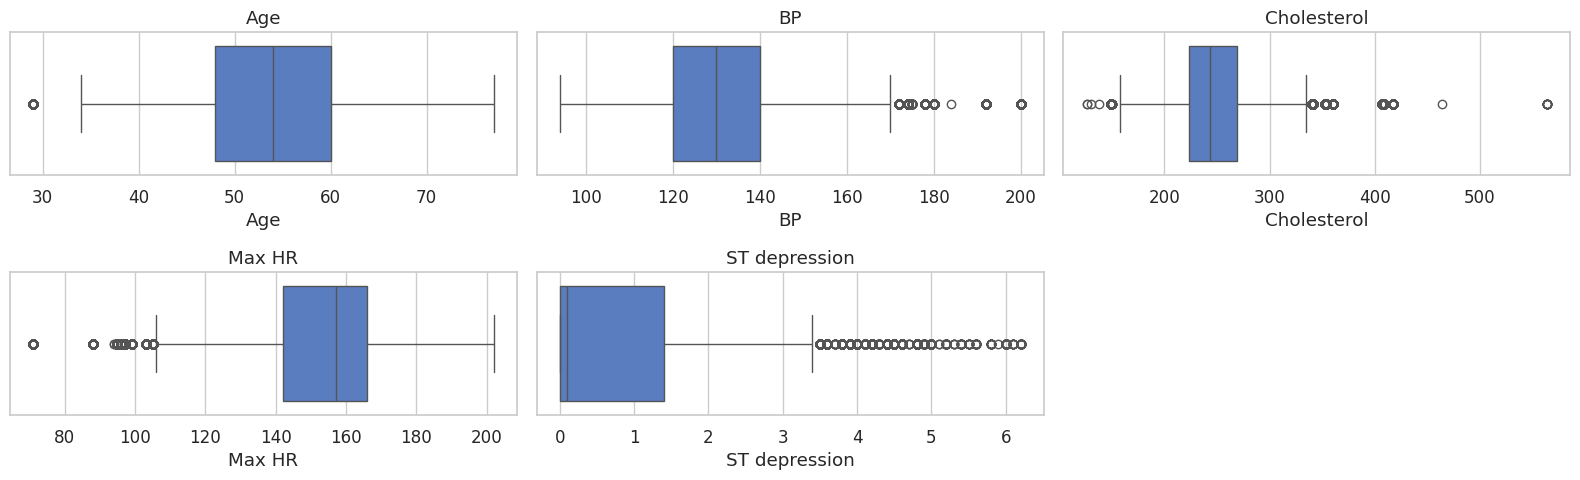

In [8]:
fig,ax = plt.subplots(2,3,figsize = (16,5))
sns.boxplot(x = train_df['Age'],ax = ax[0,0])
ax[0,0].set_title('Age')
sns.boxplot(x = train_df['BP'], ax = ax[0,1])
ax[0,1].set_title('BP')
sns.boxplot(x = train_df['Cholesterol'], ax = ax[0,2])
ax[0,2].set_title('Cholesterol')
sns.boxplot(x = train_df['Max HR'], ax = ax[1,0])
ax[1,0].set_title('Max HR')
sns.boxplot(x = train_df['ST depression'], ax = ax[1,1])
ax[1,1].set_title('ST depression')
ax[1,2].set_visible(False)
plt.tight_layout()

In [9]:
print(train_df["Heart Disease"].value_counts())

print("--Percentage of samples of Patients with  heart disease and without heart disease--")

print(train_df["Heart Disease"].value_counts(normalize=True))

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64
--Percentage of samples of Patients with  heart disease and without heart disease--
Heart Disease
Absence     0.55166
Presence    0.44834
Name: proportion, dtype: float64


<Axes: xlabel='Heart Disease', ylabel='count'>

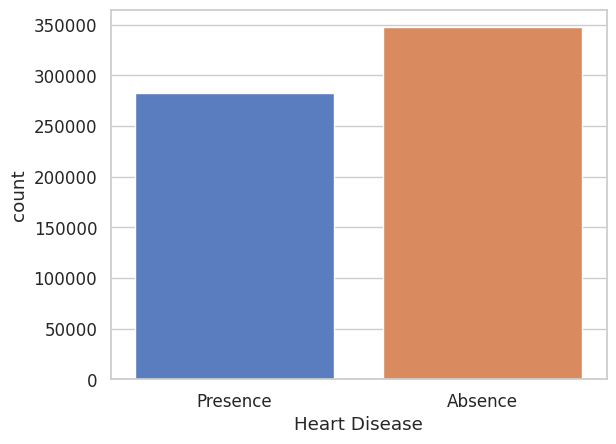

In [10]:
sns.countplot(train_df , x = train_df["Heart Disease"] , hue="Heart Disease")

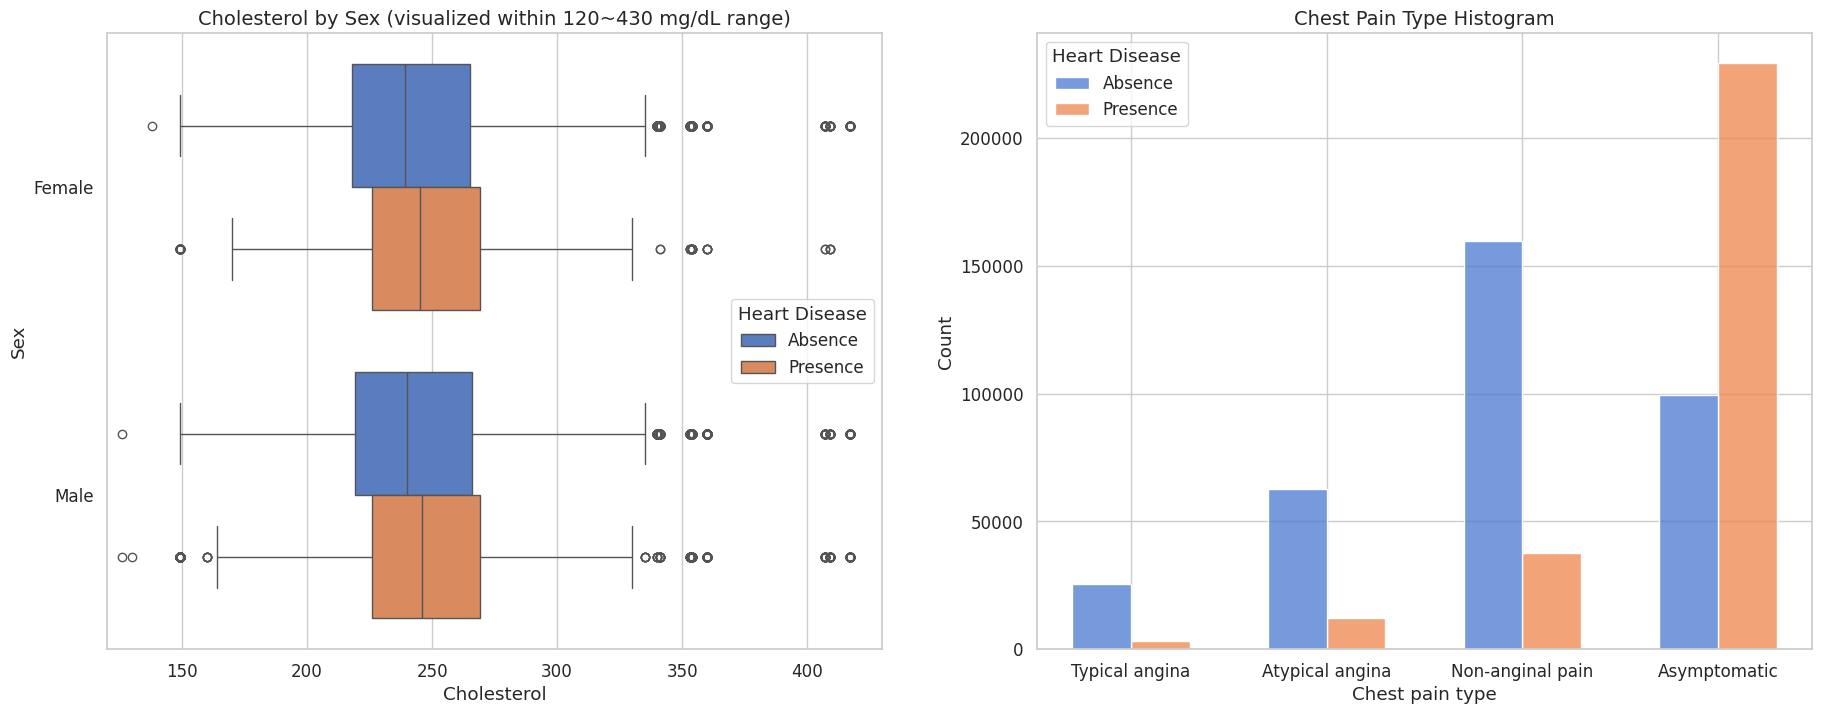

In [11]:
fig, ax = plt.subplots(1,2, figsize = (22, 8))
sns.boxplot(data = train_df, x = 'Cholesterol', y = 'Sex', hue = 'Heart Disease', orient = 'h', 
            ax = ax[0], hue_order = ['Absence', 'Presence'])
ax[0].set_xlim(120,430)
sex = ['Female', 'Male']
ax[0].set_yticks([0,1])
ax[0].set_yticklabels(sex)
ax[0].set_title('Cholesterol by Sex (visualized within 120~430 mg/dL range)', fontsize = 14)

sns.histplot(data = train_df, x = 'Chest pain type', hue = 'Heart Disease', bins = [0.5, 1.5, 2.5, 3.5, 4.5],  
             ax = ax[1], multiple = 'dodge', shrink = 0.6, hue_order = ['Absence', 'Presence'])
labels = ['Typical angina','Atypical angina','Non-anginal pain','Asymptomatic']
ax[1].set_xticks([1,2,3,4])
ax[1].set_xticklabels(labels)
ax[1].set_title('Chest Pain Type Histogram', fontsize = 14);

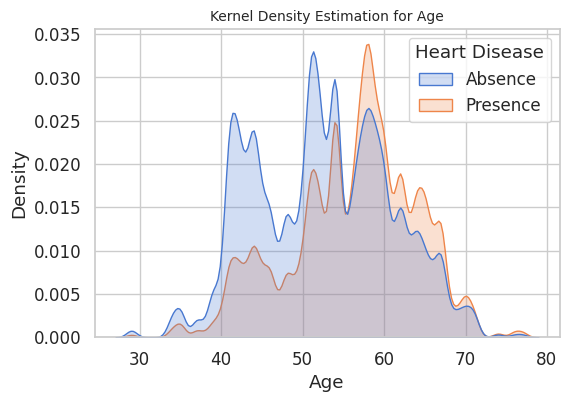

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
sns.kdeplot(data=train_df, x='Age', hue='Heart Disease', hue_order = ['Absence', 'Presence'], fill=True, ax=ax)
ax.set_title('Kernel Density Estimation for Age', fontsize = 10);

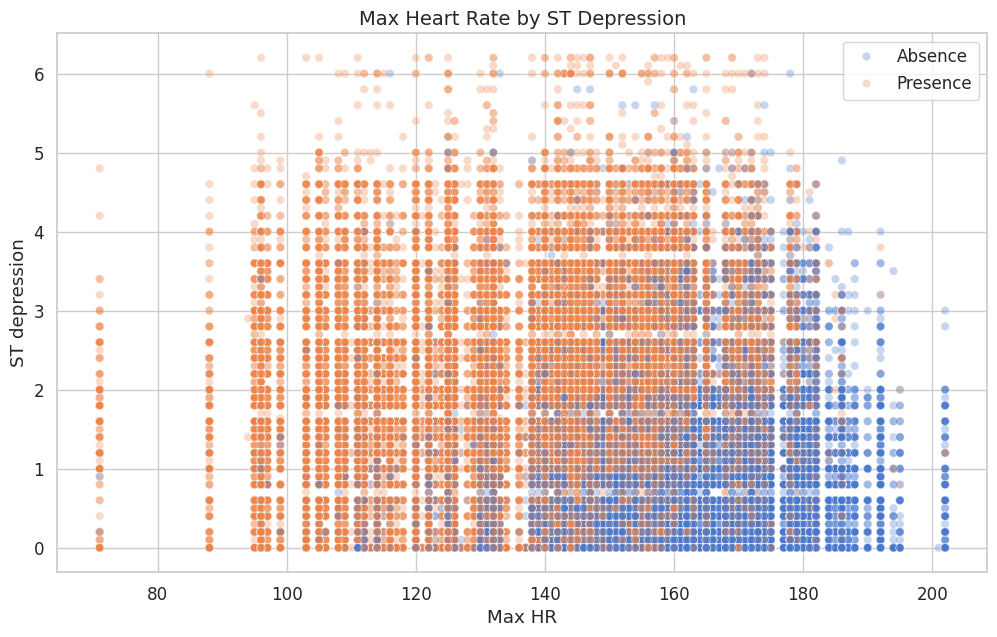

In [13]:
plt.figure(figsize = (12,7))
sns.scatterplot(data = train_df, x = 'Max HR', y = 'ST depression', 
                hue = 'Heart Disease', hue_order = ['Absence', 'Presence'], alpha = 0.3)
plt.legend()
plt.title('Max Heart Rate by ST Depression', fontsize='14');

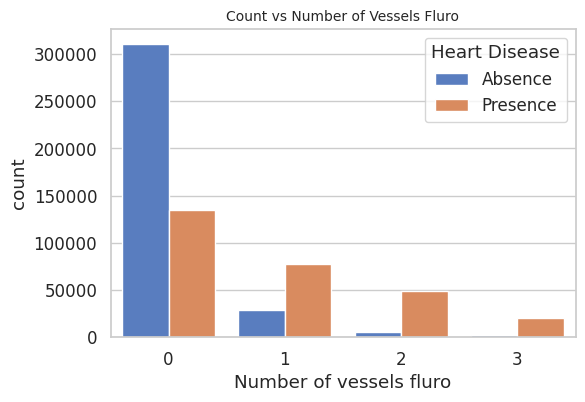

In [14]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=train_df, x='Number of vessels fluro',
    hue='Heart Disease', hue_order = ['Absence', 'Presence'], ax = ax)
ax.set_title('Count vs Number of Vessels Fluro', fontsize = 10);

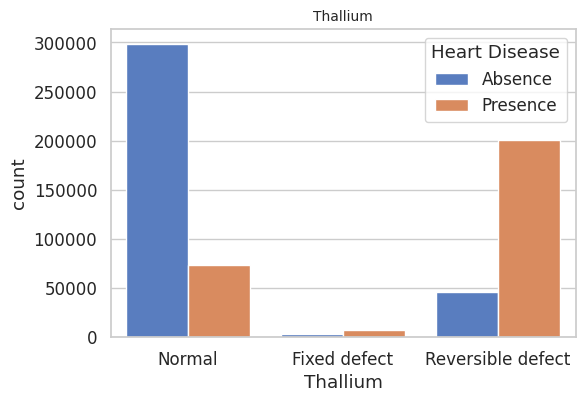

In [15]:
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=train_df, x='Thallium',
    hue='Heart Disease', hue_order = ['Absence', 'Presence'], ax = ax)
ax.set_title('Thallium', fontsize = 10);
ax.set_xticks([0,1,2])
ax.set_xticklabels(['Normal','Fixed defect','Reversible defect']);

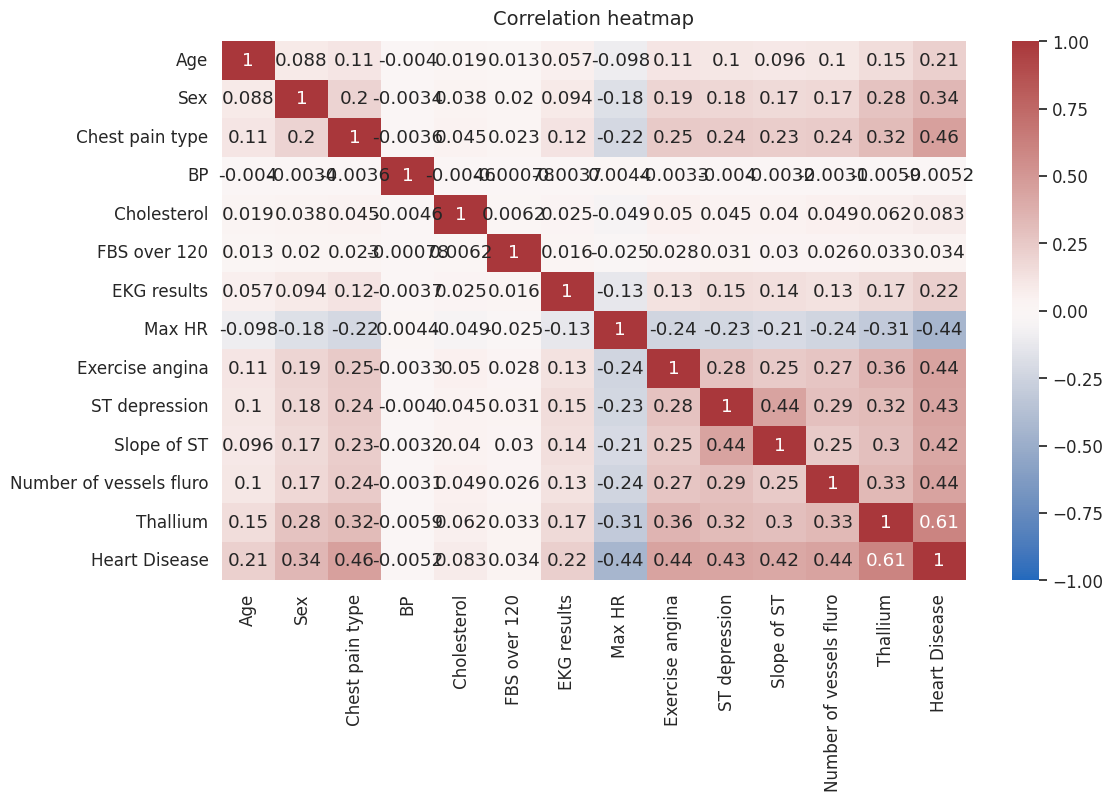

In [16]:
df_corr = train_df.drop(columns = ['id'])
df_corr['Heart Disease'] = df_corr['Heart Disease'].map({'Absence':0, 'Presence':1})

plt.figure(figsize = (12,7))
sns.heatmap(df_corr.corr(numeric_only = True), annot = True, cmap = 'vlag', vmax = 1, vmin = -1)
plt.title ('Correlation heatmap', fontsize = 14, pad = 12);

**Key takeaways**

- ST depression, Slope of ST, Exercise angina, Number of vessels fluoro, and Thallium show moderate positive associations with heart disease, suggesting they capture related stress-test and imaging signals.
- Max heart rate exhibits a moderate negative relationship with disease, indicating that higher exercise capacity is more common among healthier patients.
- Chest pain type, sex, and age also demonstrate meaningful associations with heart disease, highlighting the role of symptom presentation and demographic risk factors

# Step 3: Preprocessing and Feature Engineering

We will train the following models:
- Logistic regression
- Linear DiscriminantAnalysis
- Naive Bayes
- KNN
- SVM
- Decision Tree
- Random Forest
- Extra Trees
- Gradient Boosting
- AdaBoot
- XGBoost
- LightGBM
- CatBoost


Logistic Regression  , Linear DiscriminantAnalysis , Naive Bayes , KNN and SVM require carefull preprocessing while tree based models are generally less sensitive to feature encoding choices.

**Drop**
- id

**Continuous variables**
(Scalling will be applied later for other models other than tree based

- Age
- BP
- Cholesterol
- Max HR
- ST Depression
- Number of vessels fluro

**Binary Variable**(0/1)
- Sex
- FBS
- Excercise angina
**Categorical variablesOne-Hot-Encode)
  - Chest pain type
  - EKG results
  - Slope of ST
  - Thallium


The same type of preprocessing will be applied on the test dataset to make sure about the data consistency.

In [17]:
# Creating copy of training and testing datasets
train_df_copy = train_df.copy()
test_df_copy = test_df.copy()
train_df_copy.drop(columns=["id"])

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,Absence
629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,Absence
629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,Presence
629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,Presence


# Converting categorical columns to numerical through one hot encoding

In [18]:
train_df_copy.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

In [19]:
cat_cols = ["Chest pain type" , "EKG results" , "Thallium" , "Slope of ST"]
from sklearn.preprocessing import OneHotEncoder

#create encoder 
encoder = OneHotEncoder(
    drop=None,
    sparse_output = False,
    handle_unknown="ignore"

)

In [20]:
encoded_train = encoder.fit_transform(train_df_copy[cat_cols])
encoded_test = encoder.transform(test_df_copy[cat_cols])

import pandas as pd

# Get new column names
encoded_columns = encoder.get_feature_names_out(cat_cols)

# Convert to DataFrame
encoded_train_df = pd.DataFrame(encoded_train, columns=encoded_columns, index=train_df_copy.index)
encoded_test_df  = pd.DataFrame(encoded_test,  columns=encoded_columns, index=test_df_copy.index)

# Drop original categorical columns
train_df_copy = train_df_copy.drop(columns=cat_cols)
test_df_copy  = test_df_copy.drop(columns=cat_cols)

# Add encoded columns
train_df_copy = pd.concat([train_df_copy, encoded_train_df], axis=1)
test_df_copy  = pd.concat([test_df_copy,  encoded_test_df], axis=1)

In [21]:
train_df_copy.columns

Index(['id', 'Age', 'Sex', 'BP', 'Cholesterol', 'FBS over 120', 'Max HR',
       'Exercise angina', 'ST depression', 'Number of vessels fluro',
       'Heart Disease', 'Chest pain type_1', 'Chest pain type_2',
       'Chest pain type_3', 'Chest pain type_4', 'EKG results_0',
       'EKG results_1', 'EKG results_2', 'Thallium_3', 'Thallium_6',
       'Thallium_7', 'Slope of ST_1', 'Slope of ST_2', 'Slope of ST_3'],
      dtype='object')

In [22]:
train_df_copy["Heart Disease"] = train_df_copy["Heart Disease"].map({"Absence":0,"Presence":1})

# Step 4 Train Test Split

In [23]:
y = train_df_copy['Heart Disease']
X = train_df_copy.drop('Heart Disease', axis = 1)


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.25, stratify = y, random_state = 42)

# Step.5: Model Building

In [24]:
# Prepared Scalled Version for distance/linear models

scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_all_sc = scaler.transform(X)

In [25]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [26]:
# ── Define all models ─────────────────────────────────────────────────────────
MODELS = {
    'Logistic Regression'  : (LogisticRegression(max_iter=1000, random_state=SEED), True),
    'LDA'                  : (LinearDiscriminantAnalysis(), False),
    'Naive Bayes'          : (GaussianNB(), False),
    # 'KNN'                  : (KNeighborsClassifier(n_neighbors=7), True),
    # 'SVM'                  : (SVC(probability=True, random_state=SEED , kernel = "rbf"  , C = 1.0,
    #                              cache_size = 500 , max_iter = 500), True),
    'Decision Tree'        : (DecisionTreeClassifier(random_state=SEED), False),
    'Random Forest'        : (RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1), False),
    'Extra Trees'          : (ExtraTreesClassifier(n_estimators=200, random_state=SEED, n_jobs=-1), False),
    'Gradient Boosting'    : (GradientBoostingClassifier(random_state=SEED), False),
    'AdaBoost'             : (AdaBoostClassifier(random_state=SEED), False),
    'XGBoost'              : (XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                             random_state=SEED, verbosity=0), False),
    'LightGBM'             : (LGBMClassifier(random_state=SEED, verbose=-1), False),
    'CatBoost'             : (CatBoostClassifier(random_state=SEED, verbose=0), False),
}

In [27]:
from tqdm.auto import tqdm
import time

results = []

model_list = list(MODELS.items())

for name, (model, use_scaled) in tqdm(model_list, desc="Training Models", unit="model"):
    
    X_cv = X_all_sc if use_scaled else X.values
    X_tr = X_train_sc if use_scaled else X_train.values
    X_vl = X_val_sc   if use_scaled else X_val.values

    start = time.time()
    print(f"\n⏳ [{name}] Starting cross-validation...")

    try:
        cv_scores = cross_val_score(
            model, X_cv, y,
            cv=CV, scoring='roc_auc', n_jobs=-1
        )
        cv_mean = cv_scores.mean()
        cv_std  = cv_scores.std()

        # Train / Val AUC
        model.fit(X_tr, y_train)
        train_auc = roc_auc_score(y_train, model.predict_proba(X_tr)[:, 1])
        val_auc   = roc_auc_score(y_val,   model.predict_proba(X_vl)[:, 1])

    except Exception as e:
        print(f"  ⚠️ [{name}] FAILED: {e}")
        cv_mean, cv_std, train_auc, val_auc = np.nan, np.nan, np.nan, np.nan

    elapsed = time.time() - start

    results.append({
        'Model'    : name,
        'CV AUC'   : cv_mean,
        'CV Std'   : cv_std,
        'Train AUC': train_auc,
        'Val AUC'  : val_auc,
        'Time (s)' : round(elapsed, 1),
    })

    print(f"  ✅ [{name:<25}]  CV: {cv_mean:.4f} ± {cv_std:.4f}  |  "
          f"Train: {train_auc:.4f}  |  Val: {val_auc:.4f}  |  ⏱ {elapsed:.1f}s")

baseline_df = (pd.DataFrame(results)
               .sort_values('CV AUC', ascending=False)
               .reset_index(drop=True))

print("\n✅ Baseline evaluation complete!")
display(baseline_df)

Training Models:   0%|          | 0/11 [00:00<?, ?model/s]


⏳ [Logistic Regression] Starting cross-validation...
  ✅ [Logistic Regression      ]  CV: 0.9527 ± 0.0004  |  Train: 0.9526  |  Val: 0.9530  |  ⏱ 6.6s

⏳ [LDA] Starting cross-validation...
  ✅ [LDA                      ]  CV: 0.9513 ± 0.0004  |  Train: 0.9513  |  Val: 0.9515  |  ⏱ 5.0s

⏳ [Naive Bayes] Starting cross-validation...
  ✅ [Naive Bayes              ]  CV: 0.7951 ± 0.0011  |  Train: 0.7947  |  Val: 0.7964  |  ⏱ 2.0s

⏳ [Decision Tree] Starting cross-validation...
  ✅ [Decision Tree            ]  CV: 0.8242 ± 0.0006  |  Train: 1.0000  |  Val: 0.8235  |  ⏱ 17.6s

⏳ [Random Forest] Starting cross-validation...
  ✅ [Random Forest            ]  CV: 0.9489 ± 0.0005  |  Train: 1.0000  |  Val: 0.9491  |  ⏱ 487.5s

⏳ [Extra Trees] Starting cross-validation...
  ✅ [Extra Trees              ]  CV: 0.9478 ± 0.0004  |  Train: 1.0000  |  Val: 0.9479  |  ⏱ 399.0s

⏳ [Gradient Boosting] Starting cross-validation...
  ✅ [Gradient Boosting        ]  CV: 0.9538 ± 0.0004  |  Train: 0.9539  |  

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  ✅ [LightGBM                 ]  CV: 0.9547 ± 0.0004  |  Train: 0.9556  |  Val: 0.9551  |  ⏱ 34.3s

⏳ [CatBoost] Starting cross-validation...
  ✅ [CatBoost                 ]  CV: 0.9551 ± 0.0004  |  Train: 0.9598  |  Val: 0.9555  |  ⏱ 379.9s

✅ Baseline evaluation complete!


,Model,CV AUC,CV Std,Train AUC,Val AUC,Time (s)
0,CatBoost,0.955063,0.000437,0.959798,0.955504,379.9
1,LightGBM,0.954714,0.000415,0.955644,0.955062,34.3
2,XGBoost,0.954640,0.000407,0.958845,0.955029,19.6
3,Gradient Boosting,0.953769,0.000431,0.953930,0.954000,399.9
4,AdaBoost,0.952817,0.000486,0.952775,0.952965,91.0
5,Logistic Regression,0.952679,0.000400,0.952590,0.952988,6.6
6,LDA,0.951338,0.000358,0.951266,0.951509,5.0
7,Random Forest,0.948888,0.000503,1.000000,0.949112,487.5
8,Extra Trees,0.947843,0.000388,1.000000,0.947920,399.0
9,Decision Tree,0.824237,0.000568,1.000000,0.823487,17.6


# Baseline Visualization

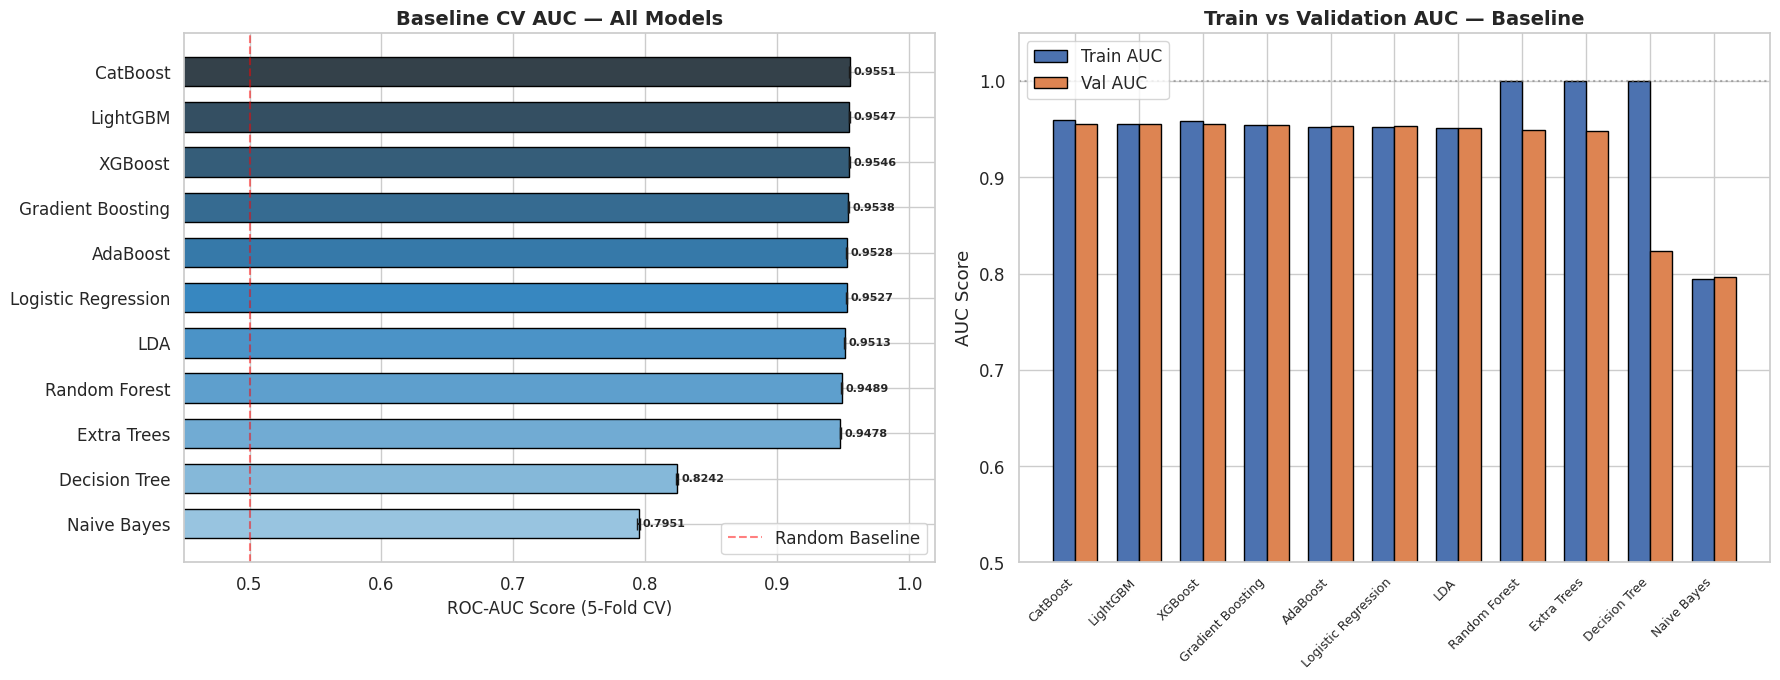

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: CV AUC bar chart ────────────────────────────────────────────────────
palette = sns.color_palette('Blues_d', n_colors=len(baseline_df))
bars = axes[0].barh(
    baseline_df['Model'][::-1], baseline_df['CV AUC'][::-1],
    xerr=baseline_df['CV Std'][::-1],
    color=palette, edgecolor='black', capsize=4, height=0.65
)
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random Baseline')
axes[0].set_xlabel('ROC-AUC Score (5-Fold CV)', fontsize=12)
axes[0].set_title('Baseline CV AUC — All Models', fontsize=14, fontweight='bold')
axes[0].set_xlim(0.45, 1.02)
for bar, val in zip(bars, baseline_df['CV AUC'][::-1]):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=8, fontweight='bold')
axes[0].legend()

# ── Right: Train vs Val grouped bar ──────────────────────────────────────────
x   = np.arange(len(baseline_df))
w   = 0.35
axes[1].bar(x - w/2, baseline_df['Train AUC'], width=w,
            label='Train AUC', color='#4C72B0', edgecolor='black')
axes[1].bar(x + w/2, baseline_df['Val AUC'],   width=w,
            label='Val AUC',   color='#DD8452', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(baseline_df['Model'], rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('AUC Score')
axes[1].set_title('Train vs Validation AUC — Baseline', fontsize=14, fontweight='bold')
axes[1].set_ylim(0.5, 1.05)
axes[1].legend()
axes[1].axhline(1.0, color='grey', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

from above visualizations , it is obvious that catboost outperform. So we will go will the catboost further now.

# Predictions

In [29]:
# reuse the already fitted catboost model from the baseline loop 
cat_model = MODELS["CatBoost"][0]

In [33]:
# Validation Set predictions
y_val_prob  = cat_model.predict_proba(X_val)[:, 1]
y_val_pred  = cat_model.predict(X_val)


# Evaluation

 CatBoost Validation Performanance
ROC_AUC SCORE : 0.9555
 ACCURACY SCORE : 0.8892

 CLASSIFICATION REPORT----------
               precision    recall  f1-score   support

   No Disease       0.89      0.91      0.90     86887
Heart Disease       0.88      0.87      0.88     70613

     accuracy                           0.89    157500
    macro avg       0.89      0.89      0.89    157500
 weighted avg       0.89      0.89      0.89    157500



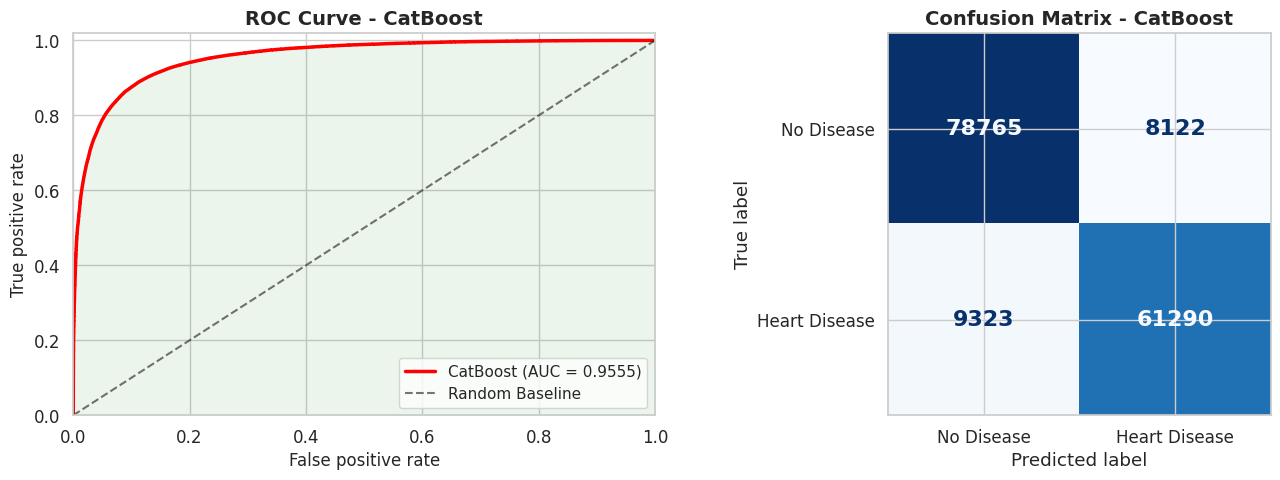

In [44]:
#Metrics 
auc_score = roc_auc_score(y_val , y_val_prob)
acc_score = accuracy_score(y_val , y_val_pred)


print("=" *55)
print(" CatBoost Validation Performanance")
print("=" *55)
print(f"ROC_AUC SCORE : {auc_score:.4f}")
print(f" ACCURACY SCORE : {acc_score:.4f}")
print("=" *55)


print("\n CLASSIFICATION REPORT----------")
print(classification_report(y_val , y_val_pred , target_names = ["No Disease" , "Heart Disease"]))

# Plots - ROC Curve + Confsuion Matrix
fig , axes = plt.subplots(1,2,figsize=(14 , 5))


# Plot ROC Curve
fpr , tpr , _ = roc_curve(y_val , y_val_prob)
axes[0].plot(fpr , tpr , color = "red" , lw = 2.5, label = f"CatBoost (AUC = {auc_score:.4f})" )

axes[0].plot([0,1] , [0,1] , "k--" , lw=1.5 , alpha = 0.6 , label = "Random Baseline")
axes[0].fill_between(fpr , tpr , alpha = 0.08 , color = "green")
axes[0].set_xlabel("False positive rate" , fontsize = 12)
axes[0].set_ylabel("True positive rate" , fontsize = 12)
axes[0].set_title("ROC Curve - CatBoost" , fontsize = 14 , fontweight = "bold")
axes[0].legend(fontsize= 11)
axes[0].set_xlim([0,1])
axes[0].set_ylim([0,1.02])



# # Confusion Matrix
cm = confusion_matrix(y_val , y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm , display_labels = ["No Disease" , "Heart Disease"])
disp.plot(ax = axes[1] , cmap = "Blues" , colorbar = False)
axes[1].set_title("Confusion Matrix - CatBoost" , fontsize = 14 , fontweight = "bold")


# annot  TN / FP / FN / TP labels
for text in axes[1].texts:
    text.set_fontsize(16)
    text.set_fontweight("bold")


plt.tight_layout()
plt.show()






In [45]:
# Refit the CatBoost on 100% of training data 
print("\n Refitting CatBoost on full training data (no validation split)-----------")

final_cat = CatBoostClassifier(random_state = SEED , verbose=0)
final_cat.fit(X.values , y)

print("Final CatBoost fitted on 100% training data!")


 Refitting CatBoost on full training data (no validation split)-----------
Final CatBoost fitted on 100% training data!


In [63]:
# test_ids = test_df_copy["id"].values
# X_test = X_test[X.columns]
X_test["id"] = test_ids


 prediction Stats: 
 Min prob : 0.0000
 Max prob : 1.0000
 Mean prob: 0.4484


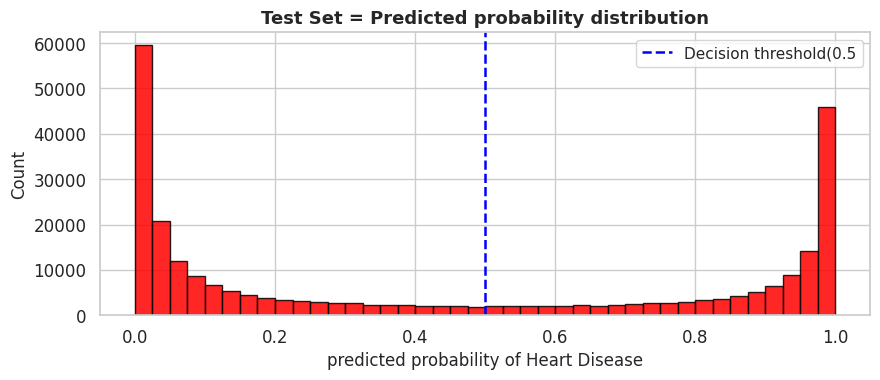

In [64]:
# Predict on tesr set---------------------------
# test_ids = test_df_copy["id"].values
# X_test = test_df_copy.drop(columns = ["id"] , errors = "ignore")
X_test = X_test[X.columns]

test_probs = final_cat.predict_proba(X_test.values)[:,1]

print("\n prediction Stats: ")
print(f" Min prob : {test_probs.min():.4f}")
print(f" Max prob : {test_probs.max():.4f}")
print(f" Mean prob: {test_probs.mean():.4f}")


#Pobability distribution Plot
fig , ax = plt.subplots(figsize = (9, 4))
ax.hist(test_probs , bins = 40 , color = "red" , edgecolor = "black" , alpha = 0.85)
ax.axvline(0.5 , color = "blue",  linestyle = "--" , lw = 1.8  , label = "Decision threshold(0.5")
ax.set_xlabel("predicted probability of Heart Disease" , fontsize = 12)
ax.set_ylabel("Count" , fontsize = 12)
ax.set_title("Test Set = Predicted probability distribution" , fontsize = 13 , fontweight = "bold")
ax.legend(fontsize = 11)
plt.tight_layout()
plt.show()

In [67]:
final_cat.save_model("/kaggle/working/CatBoostModel.cbm")
print("Model Saved")

Model Saved


# Build & Save Submission


In [66]:
submission = pd.DataFrame({
    "id" : test_ids , 
    "Heart Disease" : test_probs,
})

submission.to_csv("submission.csv" , index = False)

print("\n" + "="* 45)
print("Submission.cvs saved successfully!")
print("=" * 45)
print(f" Rows : {len(submission)}")
print(f" Columns : {len(submission.columns)}")
print()
print(submission.head(10))



Submission.cvs saved successfully!
 Rows : 270000
 Columns : 2

       id  Heart Disease
0  630000       0.953049
1  630001       0.006826
2  630002       0.993051
3  630003       0.001577
4  630004       0.272740
5  630005       0.984891
6  630006       0.001400
7  630007       0.707359
8  630008       0.989911
9  630009       0.008012
